# H06：T+1 全天最高价标签的单变量重训

本 Notebook 执行 [README 的 H06](README.md#h06-次日全天最高价标签的单变量重训)。
买入保留 T 连续竞价 `[14:31,14:36)` VWAP；退出改为下一正式交易日全天最高成交价，包含集合竞价。
收益经两日因子调整后，在 T 原 Feature universe 内排名，严格 `rank > 0.9` 为机会。

## 结果摘要

**B组原主候选（Ridge + L2 / 扩展历史）**：134个开发日命中 **2,190/6,700（32.69%）**；原后续17日命中 **273/850（32.12%）**，平均每50只中命中 **16.06只**。
同一新事件下，原模型名单后续命中率为 **3.88%**，成交额规则为 **19.06%**，随机期望约 **10%**。

主候选后续相对成交额的保守差为 **+13.06个百分点**，5日区块双侧95%名义区间为 **[+5.18, +19.88]个百分点**。
纯日频消融命中率为 **31.65%**，与主候选的配对差区间跨零。开发段动量规则为 **32.88%**，与主候选 **32.69%** 接近。

这是已查看历史上的探索性实验；最高价只是事后监督目标，不证明卖出可实现性或新的独立泛化。研究状态和结论由 README 的 H06 拥有。


## 证据说明索引

以下说明于 2026-09-24 从同主题 README 整理迁入，保存各节标注日期的方案、事实与当时解释；迁移不是新的运行或事前登记。当前假设、状态、结论和决定由 [README](README.md) 拥有。历史归档中的源码、Notebook、输入、验收快照和保留期继续有效，精确复现按对应归档说明执行。

- [H06 2026-09-22 冻结方案与验收](#h06-protocol)
- [H06 2026-09-22 结果、失败与归档](#h06-evidence)
- [H06 2026-09-23 原因诊断的背景与当时解释](#h06-cause-l2-diagnostics)
- [H06 2026-09-23 补充结果与模型行为](#h06-model-diagnostics)
- [H06 2026-09-23 当时 L2 覆盖与表达核对](#h06-l2-coverage)
- [H06 2026-09-23 当时提出的研究方向与对照设计](#h06-research-directions)
- [H06 2026-09-23 补充统计来源与只读复算](#h06-diagnostics-reproduce)
- [H06 重训结果的精确恢复](#h06-reproduce)


## 1. 方法与来源

A 为181个目标日、102个开发评价日；B 为213个目标日、134个开发评价日。共同开发段102日，后续段17日，均沿用修复后实验。
八配置、39列特征、月度训练、近60日/扩展历史、每日50只和原主候选角色固定。

### 关键假设

- 日内分钟与复权因子使用当前更正版本；历史真实到达时刻未知。P 22:00特征就绪、T+1 22:00标签可用是既有情景假设。
- 原训练标签与新训练标签的成熟可用日期相同；全日最高价不进入当日特征。
- 原模型名单另用新事件评价，分离“换评价事件”和“用新标签重训”。
- 源文件、代码和环境复制至独立证据目录；原输入只读。无需网络、broker或生产写凭证。

In [1]:
import importlib.metadata
import json
import math
import runpy
import shutil
import subprocess
import tarfile
import tempfile
from datetime import date
from itertools import pairwise
from pathlib import Path
from typing import TypedDict

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.compute as pc
import pyarrow.parquet as pq
from IPython.display import display
from matplotlib import font_manager
from matplotlib.ticker import PercentFormatter
from scipy.stats import rankdata
from sklearn.metrics import f1_score, precision_score, recall_score
from threadpoolctl import threadpool_limits

from src.access import Access, meta
from src.data_system.builders.level2_stock_trade_1m import STOCK_TRADE_1M_SCHEMA
from src.data_system.builders.stock_1430 import _label_window_vwap, _positive_ratio
from src.utils import table_ops
from src.utils.path import PathManager
from src.utils.price_utils import apply_asof_price_adjustment

source_root = Path("/home/wsw/app/dev/trading")
topic = source_root / "research/subscription-training"
prior = Path(
    "/home/wsw/app/research-evidence/subscription-repaired-2026-09-22-2ans6qng"
)
storage_root = Path("/home/wsw/app/data")
evidence = Path(
    tempfile.mkdtemp(prefix="subscription-next-high-2026-09-22-", dir=prior.parent)
)
print(f"EVIDENCE={evidence}", flush=True)
api = runpy.run_path(str(topic / "validate_training.py"))
write_json = api["_write_json"]
sha256 = api["_sha256"]
parameters = json.loads((prior / "parameters.json").read_text())
parameters["label"] = (
    "T entry-window VWAP to T+1 all AUCTION/CONTINUOUS max(high), factor adjusted"
)
parameters["selection_performed"] = False
parameters["prior"] = str(prior)
write_json(evidence / "parameters.json", parameters)
for name in ["README.md", "next_day_high.ipynb", "validate_training.py"]:
    shutil.copy2(topic / name, evidence / f"source-{name}")
with tarfile.open(evidence / "source.tar", "w") as archive:
    for path in [
        *sorted((source_root / "src").rglob("*.py")),
        source_root / "pyproject.toml",
        source_root / "uv.lock",
        source_root / "src/config/base.yml",
    ]:
        archive.add(path, arcname=str(path.relative_to(source_root)))
assert sha256(topic / "validate_training.py") == sha256(
    prior / "source-validate_training.py"
)
write_json(
    evidence / "run.json",
    {
        "base_commit": subprocess.check_output(
            ["git", "rev-parse", "HEAD"], cwd=source_root, text=True
        ).strip(),
        "worktree_before": subprocess.check_output(
            ["git", "status", "--short"], cwd=source_root, text=True
        ),
        "source_archive_sha256": sha256(evidence / "source.tar"),
        "notebook_sha256": sha256(evidence / "source-next_day_high.ipynb"),
        "preregistration_sha256": sha256(evidence / "source-README.md"),
        "versions": {
            name: importlib.metadata.version(name)
            for name in [
                "numpy",
                "pandas",
                "pyarrow",
                "scikit-learn",
                "scipy",
                "joblib",
                "matplotlib",
            ]
        },
    },
)
font_path = evidence / "NotoSansCJKsc-Regular.otf"
shutil.copy2(prior / font_path.name, font_path)
font_manager.fontManager.addfont(str(font_path))
plt.rcParams.update(
    {
        "font.family": font_manager.FontProperties(fname=font_path).get_name(),
        "font.size": 11,
        "axes.unicode_minus": False,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "figure.dpi": 120,
    }
)


class _InputFile(TypedDict):
    source: str
    path: str
    size_bytes: int
    sha256: str


def _freeze_file(source: Path, destination: Path, root: Path) -> _InputFile:
    digest = sha256(source)
    destination.parent.mkdir(parents=True, exist_ok=True)
    shutil.copy2(source, destination)
    assert sha256(destination) == digest == sha256(source)
    return {
        "source": str(source),
        "path": str(destination.relative_to(root)),
        "size_bytes": destination.stat().st_size,
        "sha256": digest,
    }

EVIDENCE=/home/wsw/app/research-evidence/subscription-next-high-2026-09-22-mg7mzsz2


## 2. 固定原实验与新增价格输入

旧面板、名单与日程复制自修复后证据；它们控制本轮的日期、特征及对照。
新增输入仅为 T/T+1 的沪深股票分钟和复权因子。复制前验证正式 Meta及直接上游存在/大小，保存直接上游 Meta身份，计算只读已复制的 Parquet。
上游逐笔不是此次计算输入，不复制全量逐笔；研究副本直接读表，不冒充可发布的正式存储根。

In [2]:
input_manifest = []
baseline_root = evidence / "baseline"
for name in [
    "panel.parquet",
    "rank-daily.parquet",
    "daily-metrics.parquet",
    "summary.csv",
    "frozen-schedule.json",
    "run.json",
    "input-manifest.json",
    "source-validate_training.py",
]:
    input_manifest.append(_freeze_file(prior / name, baseline_root / name, evidence))
for source in sorted((prior / "inputs").rglob("*")):
    if source.is_file():
        input_manifest.append(
            _freeze_file(
                source,
                baseline_root / "inputs" / source.relative_to(prior / "inputs"),
                evidence,
            )
        )
old_panel = pd.read_parquet(baseline_root / "panel.parquet")
old_rank_daily = pd.read_parquet(baseline_root / "rank-daily.parquet")
schedule = json.loads((baseline_root / "frozen-schedule.json").read_text())
original_pm = PathManager(storage_root)
sessions = Access(pm=original_pm, processed_version="v1").trade_dates(
    start_date=parameters["session_start"], end_date=parameters["session_end"]
)
assert len(sessions) == 215
assert sorted(old_panel.trade_date.unique()) == sessions[1:-1]
fact_root = evidence / "facts"
upstream_records = []
for day_index, day in enumerate(sessions[1:]):
    for dataset in ["sh_stock_trade_1m", "sz_stock_trade_1m", "adj_factor"]:
        paths = original_pm.processed_object(
            dataset_name=dataset, version="v1", trade_date=day
        )
        record = meta.require(
            pm=original_pm,
            meta_path=paths.meta_path,
            expected_payload_path=paths.payload_path,
        )
        for source in [paths.meta_path, paths.payload_path]:
            input_manifest.append(
                _freeze_file(
                    source, fact_root / source.relative_to(storage_root), evidence
                )
            )
        if record.upstream is not None:
            upstream_meta = storage_root / record.upstream[0]
            upstream = meta.require(pm=original_pm, meta_path=upstream_meta)
            saved = evidence / "upstream-metadata" / record.upstream[0]
            input_manifest.append(_freeze_file(upstream_meta, saved, evidence))
            upstream_records.append(
                {
                    "meta_path": str(record.upstream[0]),
                    "payload": str(upstream.payload_path.relative_to(storage_root)),
                    "size_bytes": upstream.payload_path.stat().st_size,
                }
            )
    if day_index % 30 == 0:
        print(f"冻结价格输入 {day_index + 1}/{len(sessions) - 1}: {day}", flush=True)
write_json(evidence / "input-manifest.json", input_manifest)
write_json(evidence / "upstream-metadata.json", upstream_records)
print(
    f"冻结{len(input_manifest)}份文件，{sum(r['size_bytes'] for r in input_manifest):,}字节；原面板{len(old_panel):,}行。"
)

冻结价格输入 1/214: 2025-11-06


冻结价格输入 31/214: 2025-12-18


冻结价格输入 61/214: 2026-02-02


冻结价格输入 91/214: 2026-03-24


冻结价格输入 121/214: 2026-05-11


冻结价格输入 151/214: 2026-06-23


冻结价格输入 181/214: 2026-08-04


冻结价格输入 211/214: 2026-09-15


冻结3220份文件，6,206,672,670字节；原面板1,103,651行。


## 3. 构造并核验价格标签

复用正式买入窗口和复权函数；只新增全日最高价聚合与候选排名。全日包含竞价，不把最高价限制在14:30之后。
同一输入另外重算原14:30退出排名，必须与全部213日冻结旧标签逐值一致；新收益应不小于旧收益，但**横截面排名和前10%成员不一定保持不变**。

In [3]:
def _daily_prices(
    minutes: pa.Table, factors: pd.DataFrame, trade_date: str
) -> pd.DataFrame:
    high = (
        minutes.select(["symbol", "high"])
        .group_by("symbol", use_threads=False)
        .aggregate([("high", "max")])
        .to_pandas()
        .set_index("symbol")["high_max"]
    )
    continuous = minutes.filter(pc.equal(minutes["phase"], 2))
    continuous_high = (
        continuous.select(["symbol", "high"])
        .group_by("symbol", use_threads=False)
        .aggregate([("high", "max")])
        .to_pandas()
        .set_index("symbol")["high_max"]
    )
    prices = pd.DataFrame(
        {
            "raw_high": high,
            "raw_continuous_high": continuous_high,
            "raw_window": _label_window_vwap(
                minutes, trade_date=date.fromisoformat(trade_date)
            ),
        }
    )
    prices["adj_factor"] = factors.set_index("symbol")["adj_factor"].reindex(
        prices.index
    )
    return apply_asof_price_adjustment(
        prices,
        adjustment="hfq",
        asof_date=trade_date,
        price_columns=("raw_high", "raw_continuous_high", "raw_window"),
        output_prefix="adjusted_",
    )


def _price_labels(
    keys: pd.DataFrame, entry: pd.DataFrame, exit_prices: pd.DataFrame
) -> pd.DataFrame:
    result = keys.copy()
    symbols = result["symbol"]
    result["entry_adjusted"] = symbols.map(entry["adjusted_raw_window"])
    result["exit_window_adjusted"] = symbols.map(exit_prices["adjusted_raw_window"])
    result["exit_high_adjusted"] = symbols.map(exit_prices["adjusted_raw_high"])
    result["old_return"] = (
        _positive_ratio(result["exit_window_adjusted"], result["entry_adjusted"]) - 1
    )
    result["high_return"] = (
        _positive_ratio(result["exit_high_adjusted"], result["entry_adjusted"]) - 1
    )
    result["old_rank"] = result["old_return"].rank(method="average", pct=True)
    result["high_rank"] = result["high_return"].rank(method="average", pct=True)
    return result


# 人工已知答案：周五买入，下一正式交易日周一；竞价高点、除权、缺失、严格0.9边界。
fixture_day = "2026-09-18"
fixture = pa.table(
    {
        "symbol": ["a", "a", "a", "b", "b"],
        "minute_start_ts_utc": [
            api["_timestamp"](fixture_day, 9, 25),
            api["_timestamp"](fixture_day, 14, 31),
            api["_timestamp"](fixture_day, 14, 36),
            api["_timestamp"](fixture_day, 14, 31),
            api["_timestamp"](fixture_day, 15),
        ],
        "phase": [0, 2, 2, 2, 0],
        "high": [12.0, 10.0, 11.0, 20.0, 24.0],
        "notional_sum": [120.0, 100.0, 110.0, 200.0, 240.0],
        "volume_sum": [10, 10, 10, 10, 10],
    }
)
fixture_factors = pd.DataFrame({"symbol": ["a", "b"], "adj_factor": [1.0, 1.0]})
fixture_prices = _daily_prices(fixture, fixture_factors, fixture_day)
assert fixture_prices.loc["a", "raw_window"] == 10
assert fixture_prices.loc["a", "raw_high"] == 12
assert fixture_prices.loc["b", "raw_high"] == 24
assert fixture_prices.loc["a", "raw_continuous_high"] == 11
fixture_exit = fixture_prices.copy()
fixture_exit.loc["a", "adjusted_raw_high"] = 6 * 2
fixture_exit.loc["b", "adjusted_raw_high"] = 24
fixture_keys = pd.DataFrame({"symbol": ["a", "b", "missing"]})
fixture_labels = _price_labels(fixture_keys, fixture_prices, fixture_exit)
np.testing.assert_allclose(fixture_labels.high_return.iloc[:2], [0.2, 0.2])
np.testing.assert_allclose(fixture_labels.high_rank.iloc[:2], [0.75, 0.75])
assert pd.isna(fixture_labels.high_rank.iloc[2])
assert not pd.Series([0.9]).gt(parameters["strict_event_threshold"]).iloc[0]
assert pd.Series(range(10)).rank(pct=True).gt(0.9).sum() == 1
assert all(sessions[i + 1] > sessions[i] for i in range(len(sessions) - 1))
assert (
    Access(pm=original_pm, processed_version="v1").next_trade_date(
        trade_date="2026-06-05"
    )
    == "2026-06-08"
)
fixture_invalid = _daily_prices(
    fixture, fixture_factors.assign(adj_factor=[0.0, np.nan]), fixture_day
)
assert fixture_invalid.adjusted_raw_high.isna().all()
write_json(
    evidence / "boundary-checks.json",
    {
        "synthetic_cases_passed": [
            "auction_high",
            "entry_right_open",
            "factor_adjustment",
            "missing_symbol",
            "invalid_factor",
            "average_tie",
            "strict_threshold",
            "next_formal_session",
        ],
        "prior_information_boundaries": api["_boundary_checks"](),
    },
)

price_tables = {}
price_checks = []
for day_index, day in enumerate(sessions[1:]):
    market_tables = []
    market_symbols: set[str] = set()
    for dataset in ["sh_stock_trade_1m", "sz_stock_trade_1m"]:
        payload = (
            fact_root
            / "processed"
            / dataset
            / "v1"
            / f"trade_date={day}"
            / "data.parquet"
        )
        with pq.ParquetFile(payload) as parquet:
            assert parquet.schema_arrow.equals(
                STOCK_TRADE_1M_SCHEMA, check_metadata=False
            )
            minute = parquet.read(
                columns=[
                    "symbol",
                    "trade_date",
                    "minute_start_ts_utc",
                    "phase",
                    "high",
                    "low",
                    "notional_sum",
                    "volume_sum",
                ]
            )
        table_ops.require_non_null(
            minute, minute.column_names, who="frozen minute facts"
        )
        table_ops.require_unique(
            minute,
            ("symbol", "trade_date", "minute_start_ts_utc", "phase"),
            who="frozen minute facts",
        )
        assert pc.all(pc.equal(minute["trade_date"], day)).as_py()
        assert pc.all(
            pc.is_in(minute["phase"], value_set=pa.array([0, 2], type=pa.int8()))
        ).as_py()
        symbols = set(minute["symbol"].unique().to_pylist())
        assert not market_symbols.intersection(symbols)
        market_symbols.update(symbols)
        market_tables.append(minute)
    minutes = pa.concat_tables(market_tables)
    with pq.ParquetFile(
        fact_root / "processed/adj_factor/v1" / f"trade_date={day}" / "data.parquet"
    ) as parquet:
        factors = parquet.read(
            columns=["symbol", "trade_date", "adj_factor"]
        ).to_pandas()
    table_ops.require_unique(factors, ("symbol",), who="factor inputs")
    assert factors.trade_date.eq(day).all()
    prices = _daily_prices(minutes, factors, day)
    # 独立Pandas全日最大值；每个实际买入窗口的总价量，Python整数求和避免整数溢出。
    minute_frame = minutes.to_pandas()
    independent_high = minute_frame.groupby("symbol").high.max()
    pd.testing.assert_series_equal(
        prices.raw_high.sort_index(), independent_high.sort_index(), check_names=False
    )
    observed = minute_frame.loc[
        minute_frame.phase.eq(2)
        & minute_frame.minute_start_ts_utc.ge(api["_timestamp"](day, 14, 31))
        & minute_frame.minute_start_ts_utc.lt(api["_timestamp"](day, 14, 36))
    ]
    independent_volume = (
        observed.assign(volume_sum=observed.volume_sum.astype(object))
        .groupby("symbol")
        .volume_sum.sum()
    )
    independent_window = observed.groupby(
        "symbol"
    ).notional_sum.sum() / independent_volume.astype(float)
    np.testing.assert_allclose(
        prices.raw_window.reindex(independent_window.index),
        independent_window,
        rtol=1e-14,
        atol=0,
    )
    assert np.isfinite(prices.raw_high).all() and prices.raw_high.gt(0).all()
    assert prices.raw_high.ge(prices.raw_continuous_high.fillna(-np.inf)).all()
    price_tables[day] = prices
    price_checks.append(
        {
            "trade_date": day,
            "minute_rows": len(minute_frame),
            "symbols": len(prices),
            "auction_higher_than_continuous": int(
                prices.raw_high.gt(prices.raw_continuous_high).sum()
            ),
            "max_raw_high": float(prices.raw_high.max()),
        }
    )
    if day_index % 30 == 0:
        print(f"核验分钟与价格 {day_index + 1}/{len(sessions) - 1}: {day}", flush=True)
pd.concat(price_tables, names=["trade_date", "symbol"]).reset_index().to_parquet(
    evidence / "daily-prices.parquet", index=False
)
pd.DataFrame(price_checks).to_csv(evidence / "price-checks.csv", index=False)
label_parts = []
label_checks = []
for day, exit_day in pairwise(sessions[1:]):
    with pq.ParquetFile(
        baseline_root
        / "inputs/labels/l2_stock_1430_t1_vwap_rank/v1"
        / f"trade_date={day}"
        / "data.parquet"
    ) as parquet:
        original_label = parquet.read().to_pandas()
    candidate = _price_labels(
        original_label.drop(columns="y_rank_return"),
        price_tables[day],
        price_tables[exit_day],
    )
    np.testing.assert_array_equal(
        candidate.old_rank.to_numpy(), original_label.y_rank_return.to_numpy()
    )
    both = candidate.old_return.notna() & candidate.high_return.notna()
    assert (
        candidate.loc[both, "high_return"]
        .ge(candidate.loc[both, "old_return"] - 1e-12)
        .all()
    )
    assert candidate.loc[candidate.old_rank.notna(), "high_rank"].notna().all()
    valid = candidate.high_return.notna()
    np.testing.assert_array_equal(
        candidate.loc[valid, "high_rank"],
        rankdata(candidate.loc[valid, "high_return"], method="average") / valid.sum(),
    )
    label_checks.append(
        {
            "trade_date": day,
            "rows": len(candidate),
            "known_old": int(candidate.old_rank.notna().sum()),
            "known_high": int(valid.sum()),
            "old_positive": int(candidate.old_rank.gt(0.9).sum()),
            "high_positive": int(candidate.high_rank.gt(0.9).sum()),
            "both_positive": int(
                (candidate.old_rank.gt(0.9) & candidate.high_rank.gt(0.9)).sum()
            ),
            "mean_old_return": float(candidate.old_return.mean()),
            "mean_high_return": float(candidate.high_return.mean()),
            "max_tie": int(candidate.high_rank.value_counts().max()),
        }
    )
    label_parts.append(candidate)
labels = pd.concat(label_parts, ignore_index=True)
labels.to_parquet(evidence / "candidate-labels.parquet", index=False)
label_profile = pd.DataFrame(label_checks)
label_profile.to_csv(evidence / "label-profile.csv", index=False)
assert len(label_profile) == 213
print(
    f"原窗口标签213日全部恢复；新标签{labels.high_rank.notna().sum():,}个，最大并列组{label_profile.max_tie.max()}。"
)
display(
    label_profile[
        [
            "known_old",
            "known_high",
            "old_positive",
            "high_positive",
            "both_positive",
            "mean_old_return",
            "mean_high_return",
        ]
    ]
    .mean()
    .to_frame("逐日均值")
    .round(6)
)

核验分钟与价格 1/214: 2025-11-06


核验分钟与价格 31/214: 2025-12-18


核验分钟与价格 61/214: 2026-02-02


核验分钟与价格 91/214: 2026-03-24


核验分钟与价格 121/214: 2026-05-11


核验分钟与价格 151/214: 2026-06-23


核验分钟与价格 181/214: 2026-08-04


核验分钟与价格 211/214: 2026-09-15


原窗口标签213日全部恢复；新标签1,102,682个，最大并列组9。


,逐日均值
known_old,5174.995305
known_high,5176.910798
old_positive,517.943662
high_positive,518.173709
both_positive,395.854460
mean_old_return,0.000114
mean_high_return,0.022196


## 4. 新面板与固定训练日程

只将训练器消费的 `y_rank_return` 替换为新的最高价收益排名。保存标签明细和原列名映射；没有向正式 `v1` 分区写入数据。
其余48列与原面板逐值一致；旧、新样本数一致，预测行不会因为未来缺失标签被删除。

In [4]:
panel = (
    old_panel.drop(columns="y_rank_return")
    .merge(
        labels[["symbol", "trade_date", "high_rank"]],
        on=["symbol", "trade_date"],
        how="left",
        validate="one_to_one",
        sort=False,
    )
    .rename(columns={"high_rank": "y_rank_return"})
)
panel = panel.loc[:, old_panel.columns].astype(old_panel.dtypes.to_dict())
pd.testing.assert_frame_equal(
    panel.drop(columns="y_rank_return"), old_panel.drop(columns="y_rank_return")
)
assert panel.source_date.lt(panel.trade_date).all()
assert panel.feature_ready_ts.le(panel.allocation_ts).all()
panel.to_parquet(evidence / "panel.parquet", index=False)
panels = {
    "corrected": panel.loc[
        panel.trade_date.ge(parameters["corrected_target_start"])
    ].copy(),
    "extended": panel,
}
development_dates = schedule["development"]
followup_dates = schedule["followup"]
for experiment, frame in panels.items():
    ready = frame.groupby("trade_date").label_ready_ts.max()
    expected = [
        day
        for day in ready.index
        if day <= parameters["development_end"]
        and (ready < api["_timestamp"](day, 8)).sum() >= 60
    ]
    assert expected == development_dates[experiment]
    assert len(followup_dates[experiment]) == 17
write_json(evidence / "frozen-schedule.json", schedule)
display(
    pd.DataFrame(
        [
            {
                "组": name,
                "目标日": frame.trade_date.nunique(),
                "股票日": len(frame),
                "已知新标签": int(frame.y_rank_return.notna().sum()),
                "开发日": len(development_dates[name]),
                "后续日": len(followup_dates[name]),
            }
            for name, frame in panels.items()
        ]
    )
)

,组,目标日,股票日,已知新标签,开发日,后续日
0,corrected,181,938691,937377,102,17
1,extended,213,1103651,1102117,134,17


## 5. 用新标签重训

继续使用已冻结训练实现：Ridge/浅树 × 日频/日频+L2 × 近60日/扩展历史。17日后续段只评价原固定角色；8月延续月初模型，9月1日更新。

In [5]:
all_rank_rows = []
with threadpool_limits(limits=1):
    for experiment, frame in panels.items():
        output_root = evidence / experiment
        output_root.mkdir()
        states = {}
        for window_name, window_size in parameters["windows"].items():
            state = api["_WalkForwardState"]()
            part = api["_walk_forward"](
                frame,
                evaluation_dates=development_dates[experiment],
                candidates=parameters["candidates"],
                rules=parameters["rules"] if window_name == "last60" else (),
                output_dir=output_root / f"development-{window_name}",
                seed=parameters["training_seed"],
                training_window=window_size,
                state=state,
            )
            part["method"] = part["method"].replace(
                {
                    candidate: f"{candidate}__{window_name}"
                    for candidate in parameters["candidates"]
                }
            )
            part["experiment"] = experiment
            part["stage"] = "development"
            all_rank_rows.append(part)
            states[window_name] = state
        for role, (candidate, window_name) in parameters["followup_roles"].items():
            prior_state = states[window_name]
            state = api["_WalkForwardState"](
                models=prior_state.models.copy(),
                fitted_month=prior_state.fitted_month,
                model_ready_ts=prior_state.model_ready_ts,
            )
            assert state.fitted_month == "2026-08"
            part = api["_walk_forward"](
                frame,
                evaluation_dates=followup_dates[experiment],
                candidates=(candidate,),
                rules=("baseline_amount",) if role == "primary" else (),
                output_dir=output_root / f"followup-{role}",
                seed=parameters["training_seed"],
                training_window=parameters["windows"][window_name],
                state=state,
            )
            part["method"] = part["method"].replace(
                {candidate: f"{candidate}__{window_name}"}
            )
            part["experiment"] = experiment
            part["stage"] = "followup"
            all_rank_rows.append(part)
            schedule = json.loads(
                (output_root / f"followup-{role}/fit-schedule.json").read_text()
            )
            assert len(schedule) == 1 and schedule[0]["eval_start"] == "2026-09-01"
rank_daily = pd.concat(all_rank_rows, ignore_index=True)
assert not rank_daily.duplicated(["experiment", "stage", "trade_date", "method"]).any()
rank_daily.to_parquet(evidence / "rank-daily.parquet", index=False)
print("两组固定训练完成；后续段沿用原冻结角色，未重新选择模型。")

fit ridge_daily 2026-03-27; days=60; seconds=0.05


fit ridge_all 2026-03-27; days=60; seconds=0.27


fit hist_daily 2026-03-27; days=60; seconds=0.69


fit hist_all 2026-03-27; days=60; seconds=2.92


fit ridge_daily 2026-04-01; days=60; seconds=0.05


...

fit hist_all 2026-08-03; days=178; seconds=8.48


fit ridge_all 2026-09-01; days=199; seconds=0.93


fit ridge_daily 2026-09-01; days=199; seconds=0.28


fit hist_all 2026-09-01; days=60; seconds=2.95


两组固定训练完成；后续段沿用原冻结角色，未重新选择模型。


## 6. 三种口径的机会命中

`old_old`：旧标签训练、旧事件评价；`old_high`：旧名单、新事件评价；`high_high`：新标签训练、新事件评价。
Precision分母仍为全部50只；缺失保留上下界，Recall/F1/Lift沿用H05定义。以下为日期等权平均。

In [6]:
def _add_metrics(counts: pd.DataFrame) -> pd.DataFrame:
    result = counts.copy()
    hits = result["hits"]
    selected = result["selected_count"]
    known = result["known_positive"]
    inside = result["selected_unknown"]
    outside = result["unknown_count"] - inside
    result["precision_lower"] = hits / selected
    result["precision_upper"] = (hits + inside) / selected
    result["recall_known"] = hits / known
    result["recall_lower"] = hits / (known + outside)
    result["recall_upper"] = (hits + inside) / (known + inside)
    result["f1_lower"] = 2 * hits / (selected + known + outside)
    result["f1_upper"] = 2 * (hits + inside) / (selected + known + inside)
    result["random_lower"] = known / result["pool_size"]
    result["random_upper"] = (known + result["unknown_count"]) / result["pool_size"]
    result["lift_lower"] = result["pool_size"] / selected * result["recall_lower"]
    result["lift_upper"] = result["pool_size"] / selected * result["recall_upper"]
    result["label_coverage"] = 1 - inside / selected
    return result


rows = []
label_frames = {"old_old": old_panel, "old_high": panel, "high_high": panel}
for scenario, source_rows in [
    ("old_old", old_rank_daily),
    ("old_high", old_rank_daily),
    ("high_high", rank_daily),
]:
    by_day = {
        day: frame.set_index("symbol").y_rank_return
        for day, frame in label_frames[scenario].groupby("trade_date", sort=True)
    }
    for row in source_rows.itertuples(index=False):
        event_rank = by_day[row.trade_date]
        selected = list(row.selected_symbols)
        assert len(selected) == len(set(selected)) == parameters["k"]
        chosen = event_rank.loc[selected]
        rows.append(
            {
                "scenario": scenario,
                "experiment": row.experiment,
                "stage": row.stage,
                "trade_date": row.trade_date,
                "method": row.method,
                "pool_size": len(event_rank),
                "known_positive": int(event_rank.gt(0.9).sum()),
                "unknown_count": int(event_rank.isna().sum()),
                "selected_count": len(selected),
                "selected_unknown": int(chosen.isna().sum()),
                "hits": int(chosen.gt(0.9).sum()),
                "top_rank_lower": float(chosen.fillna(0).mean()),
                "top_rank_upper": float(chosen.fillna(1).mean()),
            }
        )
daily = _add_metrics(pd.DataFrame(rows))
assert daily.known_positive.gt(0).all()
daily.to_parquet(evidence / "daily-metrics.parquet", index=False)
metric_names = [
    "precision_lower",
    "precision_upper",
    "recall_lower",
    "recall_upper",
    "f1_lower",
    "f1_upper",
    "random_lower",
    "random_upper",
    "lift_lower",
    "lift_upper",
    "label_coverage",
    "top_rank_lower",
    "top_rank_upper",
]
scoped = pd.concat(
    [
        daily.loc[daily.stage.eq("development")].assign(period="development_all"),
        daily.loc[
            daily.stage.eq("development")
            & daily.trade_date.ge(parameters["common_development_start"])
        ].assign(period="development_common"),
        daily.loc[daily.stage.eq("followup")].assign(period="followup"),
    ],
    ignore_index=True,
)
summary = (
    scoped.groupby(["scenario", "experiment", "period", "method"], sort=True)
    .agg(
        days=("trade_date", "size"),
        hits=("hits", "sum"),
        selected=("selected_count", "sum"),
        mean_hits=("hits", "mean"),
        selected_unknown=("selected_unknown", "sum"),
        **{name: (name, "mean") for name in metric_names},
    )
    .reset_index()
)
summary.to_csv(evidence / "summary.csv", index=False)
monthly = (
    daily.assign(month=daily.trade_date.str[:7])
    .groupby(["scenario", "experiment", "stage", "month", "method"])
    .agg(
        days=("trade_date", "size"),
        mean_hits=("hits", "mean"),
        **{name: (name, "mean") for name in metric_names},
    )
    .reset_index()
)
monthly.to_csv(evidence / "monthly.csv", index=False)
original_metrics = pd.read_parquet(baseline_root / "daily-metrics.parquet")
keys = ["experiment", "stage", "trade_date", "method"]
pd.testing.assert_frame_equal(
    daily.loc[daily.scenario.eq("old_old")]
    .set_index(keys)[["hits", "selected_unknown", *metric_names]]
    .sort_index(),
    original_metrics.set_index(keys)[
        ["hits", "selected_unknown", *metric_names]
    ].sort_index(),
)
labels_map = {
    "baseline_amount": "成交额规则",
    "baseline_momentum": "动量规则",
    "baseline_reversal": "反转规则",
}
for candidate, caption in [
    ("ridge_daily", "Ridge 日频"),
    ("ridge_all", "Ridge 日频+L2"),
    ("hist_daily", "浅树 日频"),
    ("hist_all", "浅树 日频+L2"),
]:
    for window, window_caption in [("last60", "近60日"), ("expanding", "扩展历史")]:
        labels_map[f"{candidate}__{window}"] = f"{caption} / {window_caption}"
main_table = summary.loc[
    summary.method.eq(parameters["primary"])
    & summary.period.isin(["development_common", "followup"]),
    [
        "scenario",
        "experiment",
        "period",
        "hits",
        "selected",
        "precision_lower",
        "precision_upper",
        "mean_hits",
        "lift_lower",
    ],
]
display(main_table.round(6))

,scenario,experiment,period,hits,selected,precision_lower,precision_upper,mean_hits,lift_lower
18,high_high,corrected,development_common,1691,5100,0.331569,0.334902,16.578431,3.268609
24,high_high,corrected,followup,276,850,0.324706,0.325882,16.235294,3.218927
44,high_high,extended,development_common,1661,5100,0.325686,0.328627,16.284314,3.210338
50,high_high,extended,followup,273,850,0.321176,0.322353,16.058824,3.183949
70,old_high,corrected,development_common,168,5100,0.032941,0.034314,1.647059,0.324326
76,old_high,corrected,followup,34,850,0.040000,0.043529,2.000000,0.396775
96,old_high,extended,development_common,124,5100,0.024314,0.024510,1.215686,0.239566
102,old_high,extended,followup,33,850,0.038824,0.040000,1.941176,0.385144
122,old_old,corrected,development_common,239,5100,0.046863,0.049020,2.343137,0.459974
128,old_old,corrected,followup,38,850,0.044706,0.048235,2.235294,0.442426


## 7. 相同新事件下的配对比较

主比较：新模型Precision下界减成交额规则上界。辅助比较：随机期望、日频消融、旧模型在同一新事件上的名单。
固定5日循环区块重采样10,000次，1/3日作敏感性检查。双侧95%区间用于展示，探索性支持采用预定单侧95%下界；未校正多重比较。

In [7]:
comparisons = []
bootstrap_audit = []
for (experiment, period), part in scoped.groupby(["experiment", "period"], sort=True):
    fresh = part.loc[part.scenario.eq("high_high")]
    by_method = {
        name: frame.sort_values("trade_date").set_index("trade_date")
        for name, frame in fresh.groupby("method")
    }
    legacy = part.loc[part.scenario.eq("old_high")]
    for method, candidate_rows in by_method.items():
        if method.startswith("baseline_"):
            continue
        comparators = {
            "baseline_amount": by_method["baseline_amount"].precision_upper,
            "random_expectation": candidate_rows.random_upper,
            "same_model_old_target": legacy.loc[legacy.method.eq(method)]
            .sort_values("trade_date")
            .set_index("trade_date")
            .precision_upper,
        }
        if "_all__" in method:
            ablation = method.replace("_all__", "_daily__")
            if ablation in by_method:
                comparators[ablation] = by_method[ablation].precision_upper
        for comparator, upper in comparators.items():
            assert candidate_rows.index.equals(upper.index)
            delta = (candidate_rows.precision_lower - upper).to_numpy()
            for block in parameters["block_lengths"]:
                rng = np.random.default_rng(parameters["bootstrap_seed"])
                starts = rng.integers(
                    0,
                    len(delta),
                    size=(
                        parameters["bootstrap_repeats"],
                        math.ceil(len(delta) / block),
                    ),
                )
                indices = (
                    (starts[:, :, None] + np.arange(block)) % len(delta)
                ).reshape(parameters["bootstrap_repeats"], -1)[:, : len(delta)]
                means = delta[indices].mean(axis=1)
                intervals = np.quantile(means, [0.025, 0.05, 0.975])
                comparisons.append(
                    {
                        "experiment": experiment,
                        "period": period,
                        "method": method,
                        "comparator": comparator,
                        "block_length": block,
                        "days": len(delta),
                        "mean_difference": float(delta.mean()),
                        "two_sided_low": float(intervals[0]),
                        "one_sided_low": float(intervals[1]),
                        "two_sided_high": float(intervals[2]),
                    }
                )
                if method == parameters["primary"] and block == 5:
                    independently_resampled = np.array(
                        [
                            np.mean(
                                [
                                    delta[(int(start) + offset) % len(delta)]
                                    for start in chosen
                                    for offset in range(block)
                                ][: len(delta)]
                            )
                            for chosen in starts
                        ]
                    )
                    np.testing.assert_array_equal(means, independently_resampled)
                    bootstrap_audit.append(
                        {
                            "experiment": experiment,
                            "period": period,
                            "comparator": comparator,
                            "repeats": len(means),
                        }
                    )
intervals = pd.DataFrame(comparisons)
intervals.to_csv(evidence / "paired-intervals.csv", index=False)
primary_intervals = intervals.loc[
    intervals.method.eq(parameters["primary"]) & intervals.block_length.eq(5)
]
display(primary_intervals.loc[primary_intervals.period.eq("followup")].round(6))

,experiment,period,method,comparator,block_length,days,mean_difference,two_sided_low,one_sided_low,two_sided_high
177,corrected,followup,ridge_all__expanding,baseline_amount,5,17,0.134118,0.064706,0.075294,0.202353
180,corrected,followup,ridge_all__expanding,random_expectation,5,17,0.223809,0.154321,0.164957,0.280249
183,corrected,followup,ridge_all__expanding,same_model_old_target,5,17,0.281176,0.196471,0.210588,0.348235
186,corrected,followup,ridge_all__expanding,ridge_daily__expanding,5,17,0.001176,-0.032941,-0.027059,0.036500
375,extended,followup,ridge_all__expanding,baseline_amount,5,17,0.130588,0.051765,0.065882,0.198824
378,extended,followup,ridge_all__expanding,random_expectation,5,17,0.220279,0.144964,0.156726,0.283853
381,extended,followup,ridge_all__expanding,same_model_old_target,5,17,0.281176,0.190588,0.204706,0.358824
384,extended,followup,ridge_all__expanding,ridge_daily__expanding,5,17,0.004706,-0.021206,-0.017647,0.034118


## 8. 独立恢复模型、名单与计数

逐个加载保存模型，恢复全部预测日；核对训练日期仅含成熟标签，特征名只有39列以内的昨日输入。
逐日用独立排序重新选50只；用布尔向量重算H/A/M，并用sklearn校验缺失事件的两种极端赋值。

In [8]:
model_reloads = []
prediction_checks = []
for experiment, frame in panels.items():
    frame_days = {day: part for day, part in frame.groupby("trade_date", sort=True)}
    fit_records = []
    for path in sorted((evidence / experiment).glob("*/fit-schedule.json")):
        for fit in json.loads(path.read_text()):
            assert fit["max_label_ready_ts"] < fit["scenario_fit_start_ts"]
            assert all(name.startswith("lag_") for name in fit["feature_names"])
            assert not any(
                "high_return" in name or "y_rank" in name
                for name in fit["feature_names"]
            )
            fitted_frame = frame.loc[frame.trade_date.isin(fit["training_dates"])]
            assert fitted_frame.label_ready_ts.max() == fit["max_label_ready_ts"]
            assert fitted_frame.y_rank_return.notna().sum() == fit["labeled_rows"]
            model_path = path.parent / f"{fit['eval_start']}-{fit['candidate']}.joblib"
            assert sha256(model_path) == fit["model_sha256"]
            estimator, preprocessor = joblib.load(model_path)
            fit_records.append(
                {
                    "directory": path.parent,
                    "fit": fit,
                    "estimator": estimator,
                    "preprocessor": preprocessor,
                }
            )
            model_reloads.append(
                {
                    "experiment": experiment,
                    "directory": path.parent.name,
                    "fit_date": fit["eval_start"],
                    "candidate": fit["candidate"],
                }
            )
    with threadpool_limits(limits=1):
        for prediction_path in sorted(
            (evidence / experiment).glob("*/predictions-*.parquet")
        ):
            prediction = pd.read_parquet(prediction_path)
            day = prediction.trade_date.iloc[0]
            target = frame_days[day]
            window = prediction_path.parent.name.split("-")[-1]
            if prediction_path.parent.name.startswith("followup-"):
                role = prediction_path.parent.name.removeprefix("followup-")
                window = parameters["followup_roles"][role][1]
            for candidate in [
                c for c in prediction.columns if c in parameters["candidates"]
            ]:
                eligible = [
                    r
                    for r in fit_records
                    if r["fit"]["candidate"] == candidate
                    and r["fit"]["eval_start"] <= day
                    and (
                        r["directory"].name == f"development-{window}"
                        or r["directory"] == prediction_path.parent
                    )
                ]
                chosen_fit = max(eligible, key=lambda r: r["fit"]["eval_start"])
                names = chosen_fit["preprocessor"].feature_names
                keep, transformed = chosen_fit["preprocessor"].transform(
                    target[list(names)].to_numpy(dtype=float)
                )
                assert keep.all()
                restored = chosen_fit["estimator"].predict(transformed)
                np.testing.assert_array_equal(
                    restored, prediction[candidate].to_numpy()
                )
                assert target.symbol.tolist() == prediction.symbol.tolist()
            prediction_checks.append(
                {
                    "experiment": experiment,
                    "path": str(prediction_path.relative_to(evidence)),
                    "rows": len(prediction),
                }
            )

checked_days = 0
sklearn_checks = 0
for experiment, part in rank_daily.groupby("experiment"):
    frame_days = {
        day: frame.set_index("symbol")
        for day, frame in panels[experiment].groupby("trade_date", sort=True)
    }
    for row in part.itertuples(index=False):
        frame = frame_days[row.trade_date]
        if row.method.startswith("baseline_"):
            scores = frame[row.method]
        else:
            candidate, window = row.method.split("__")
            if row.stage == "development":
                directory = f"development-{window}"
            else:
                role = next(
                    role
                    for role, pair in parameters["followup_roles"].items()
                    if pair == [candidate, window]
                )
                directory = f"followup-{role}"
            saved = pd.read_parquet(
                evidence
                / experiment
                / directory
                / f"predictions-{row.trade_date}.parquet"
            ).set_index("symbol")
            scores = saved[candidate]
        chosen = [
            symbol
            for symbol in sorted(
                scores.index,
                key=lambda symbol: (
                    -scores[symbol] if pd.notna(scores[symbol]) else float("inf"),
                    symbol,
                ),
            )[: parameters["k"]]
        ]
        assert chosen == list(row.selected_symbols)
        event_rank = frame.y_rank_return
        predicted = event_rank.index.isin(chosen)
        positive = event_rank.gt(0.9).to_numpy()
        unknown = event_rank.isna().to_numpy()
        daily_row = daily.loc[
            daily.scenario.eq("high_high")
            & daily.experiment.eq(experiment)
            & daily.stage.eq(row.stage)
            & daily.trade_date.eq(row.trade_date)
            & daily.method.eq(row.method)
        ].iloc[0]
        assert int((predicted & positive).sum()) == daily_row.hits
        assert int((predicted & unknown).sum()) == daily_row.selected_unknown
        assert int(positive.sum()) == daily_row.known_positive
        for bound, actual in [
            ("lower", positive | (unknown & ~predicted)),
            ("upper", positive | (unknown & predicted)),
        ]:
            for name, func in [
                ("precision", precision_score),
                ("recall", recall_score),
                ("f1", f1_score),
            ]:
                np.testing.assert_allclose(
                    daily_row[f"{name}_{bound}"],
                    func(actual, predicted, zero_division=0),
                    rtol=1e-13,
                    atol=0,
                )
            np.testing.assert_allclose(
                daily_row[f"lift_{bound}"],
                precision_score(actual, predicted, zero_division=0) / actual.mean(),
                rtol=1e-13,
                atol=0,
            )
            sklearn_checks += 1
        checked_days += 1
write_json(evidence / "model-reload-checks.json", model_reloads)
write_json(evidence / "prediction-checks.json", prediction_checks)
write_json(
    evidence / "verification.json",
    {
        "original_label_days_reproduced": len(label_profile),
        "minute_days_independently_aggregated": len(price_checks),
        "models_reloaded": len(model_reloads),
        "prediction_files_restored": len(prediction_checks),
        "model_days_reselected": checked_days,
        "sklearn_extreme_assignments": sklearn_checks,
        "main_bootstrap_checks": bootstrap_audit,
        "nonlabel_panel_columns_unchanged": True,
        "old_metrics_reproduced": True,
    },
)
print(
    f"恢复{len(model_reloads)}个模型、{len(prediction_checks)}份逐日预测；独立重选{checked_days}个模型日，sklearn核验{sklearn_checks}次。"
)

恢复110个模型、574份逐日预测；独立重选2732个模型日，sklearn核验5464次。


## 9. 相同日期的新旧机会命中对照

左右图使用相同的102个开发日，固定主候选不变。短横线为缺失标签上下界，不是置信区间。
成交额规则在旧/新事件下可能变化；“每个股票的最高价收益更高”不意味着它的排名也上升。

同一新事件下，新标签重训后各固定模型的机会命中明显增加。旧名单直接换新事件评价没有带来类似改善；两组的原主候选在共同102日分别命中33.16%和32.57%。

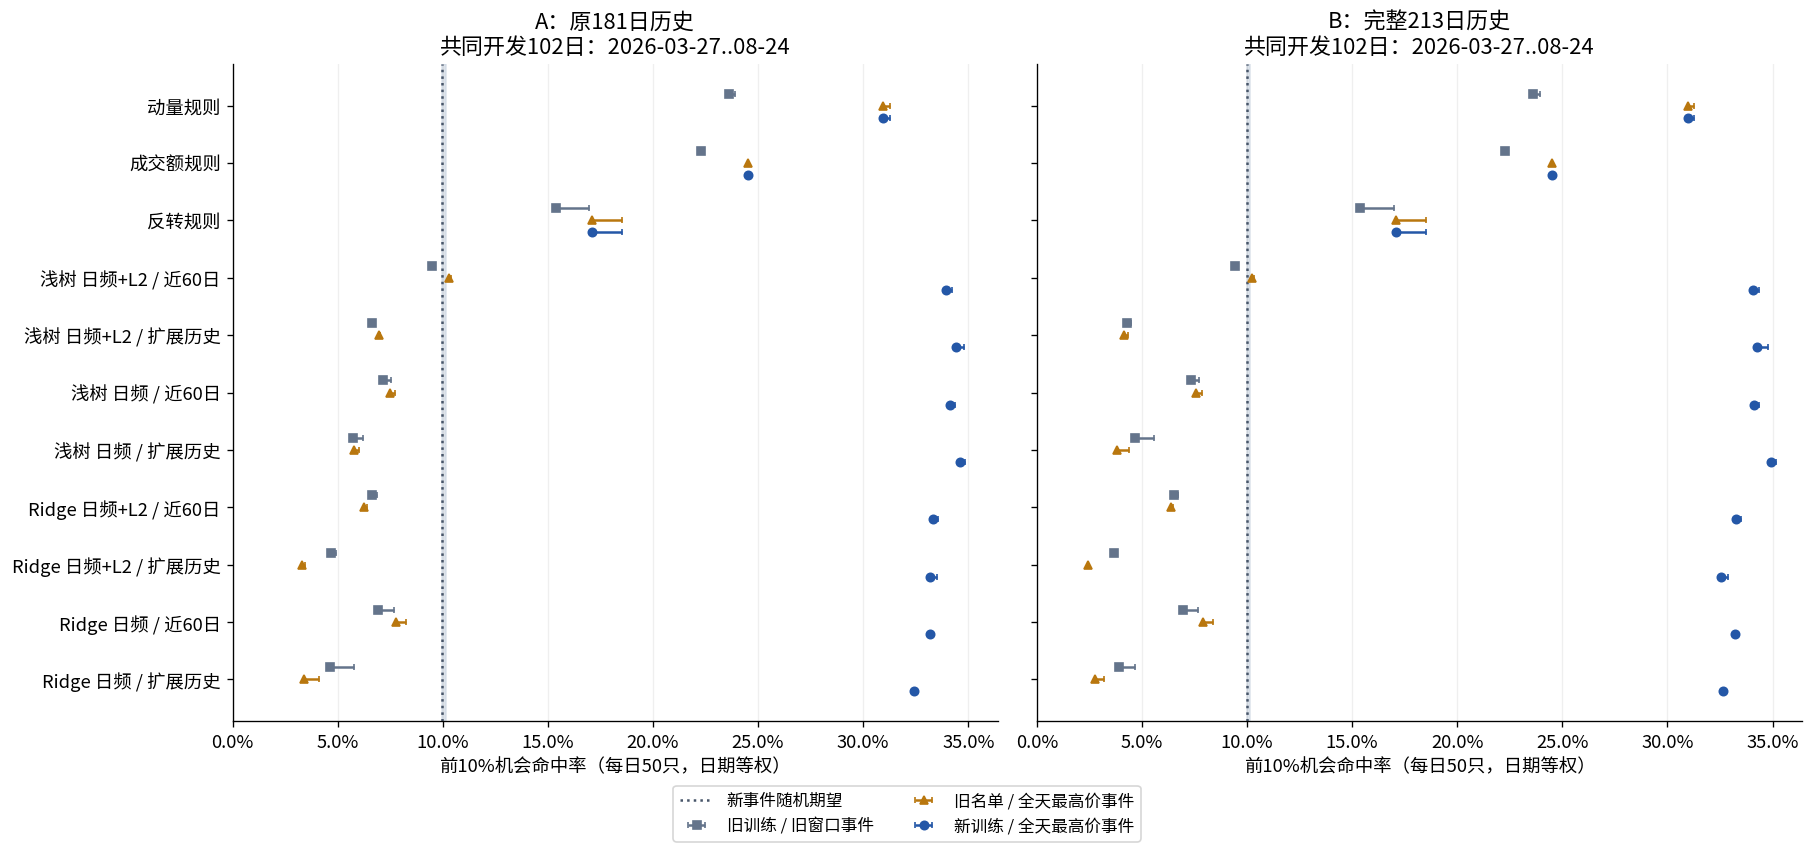

,method,days,hits,selected,precision_lower,precision_upper,lift_lower
26,baseline_amount,134,1626,6700,0.242687,0.242985,2.394689
27,baseline_momentum,134,2203,6700,0.328806,0.332537,3.247863
28,baseline_reversal,134,1105,6700,0.164925,0.176866,1.632111
29,hist_all__expanding,134,2367,6700,0.353284,0.360149,3.491729
30,hist_all__last60,134,2344,6700,0.349851,0.355075,3.457129
31,hist_daily__expanding,134,2386,6700,0.356119,0.358806,3.516777
32,hist_daily__last60,134,2305,6700,0.344030,0.346269,3.397926
33,ridge_all__expanding,134,2190,6700,0.326866,0.329552,3.227173
34,ridge_all__last60,134,2221,6700,0.331493,0.333881,3.272999
35,ridge_daily__expanding,134,2231,6700,0.332985,0.334328,3.286986


In [2]:
figure, axes = plt.subplots(
    1, 2, figsize=(15, 7), sharex=True, sharey=True, layout="constrained"
)
methods = [
    "baseline_momentum",
    "baseline_amount",
    "baseline_reversal",
    "hist_all__last60",
    "hist_all__expanding",
    "hist_daily__last60",
    "hist_daily__expanding",
    "ridge_all__last60",
    "ridge_all__expanding",
    "ridge_daily__last60",
    "ridge_daily__expanding",
]
colors = {"old_old": "#64748b", "old_high": "#b9770e", "high_high": "#2457a7"}
scenario_captions = {
    "old_old": "旧训练 / 旧窗口事件",
    "old_high": "旧名单 / 全天最高价事件",
    "high_high": "新训练 / 全天最高价事件",
}
for axis, experiment, caption in zip(
    axes, ["corrected", "extended"], ["A：原181日历史", "B：完整213日历史"], strict=True
):
    part = summary.loc[
        summary.experiment.eq(experiment) & summary.period.eq("development_common")
    ]
    for scenario, offset, marker in [
        ("old_old", -0.21, "s"),
        ("old_high", 0, "^"),
        ("high_high", 0.21, "o"),
    ]:
        rows_plot = (
            part.loc[part.scenario.eq(scenario)].set_index("method").loc[methods]
        )
        lower = rows_plot.precision_lower.to_numpy()
        upper = rows_plot.precision_upper.to_numpy()
        axis.errorbar(
            lower,
            np.arange(len(methods)) + offset,
            xerr=np.vstack([np.zeros(len(methods)), upper - lower]),
            fmt=marker,
            color=colors[scenario],
            markersize=5,
            capsize=2,
            label=scenario_captions[scenario],
        )
    random = part.loc[part.scenario.eq("high_high")].iloc[0]
    axis.axvspan(random.random_lower, random.random_upper, color="#cbd5e1", alpha=0.6)
    axis.axvline(
        random.random_lower, color="#475569", linestyle=":", label="新事件随机期望"
    )
    axis.set_title(caption + "\n共同开发102日：2026-03-27..08-24")
    axis.set_yticks(np.arange(len(methods)), [labels_map[m] for m in methods])
    axis.xaxis.set_major_formatter(PercentFormatter(1))
    axis.set_xlabel("前10%机会命中率（每日50只，日期等权）")
    axis.set_xlim(left=0)
    axis.grid(axis="x", alpha=0.2)
axes[0].invert_yaxis()
handles, legend_labels = axes[1].get_legend_handles_labels()
figure.legend(handles, legend_labels, loc="outside lower center", ncol=2, fontsize=10)
figure.savefig(evidence / "development-precision.png", dpi=160)
plt.show()
display(
    summary.loc[
        summary.scenario.eq("high_high")
        & summary.experiment.eq("extended")
        & summary.period.eq("development_all"),
        [
            "method",
            "days",
            "hits",
            "selected",
            "precision_lower",
            "precision_upper",
            "lift_lower",
        ],
    ].round(6)
)

## 10. 后续17日的固定角色与不确定性

原后续段已经被查看，本轮按历史探索解释。左图为B组每日50只的平均命中数；右图为A/B原主候选相对成交额及其旧模型名单的保守差、5日区块双侧95%名义区间。

B组重训主候选命中273个名额；纯日频为269个，浅树+L2/近60日为271个，成交额为162个。新增训练目标的变化与L2增量需要分别判断。

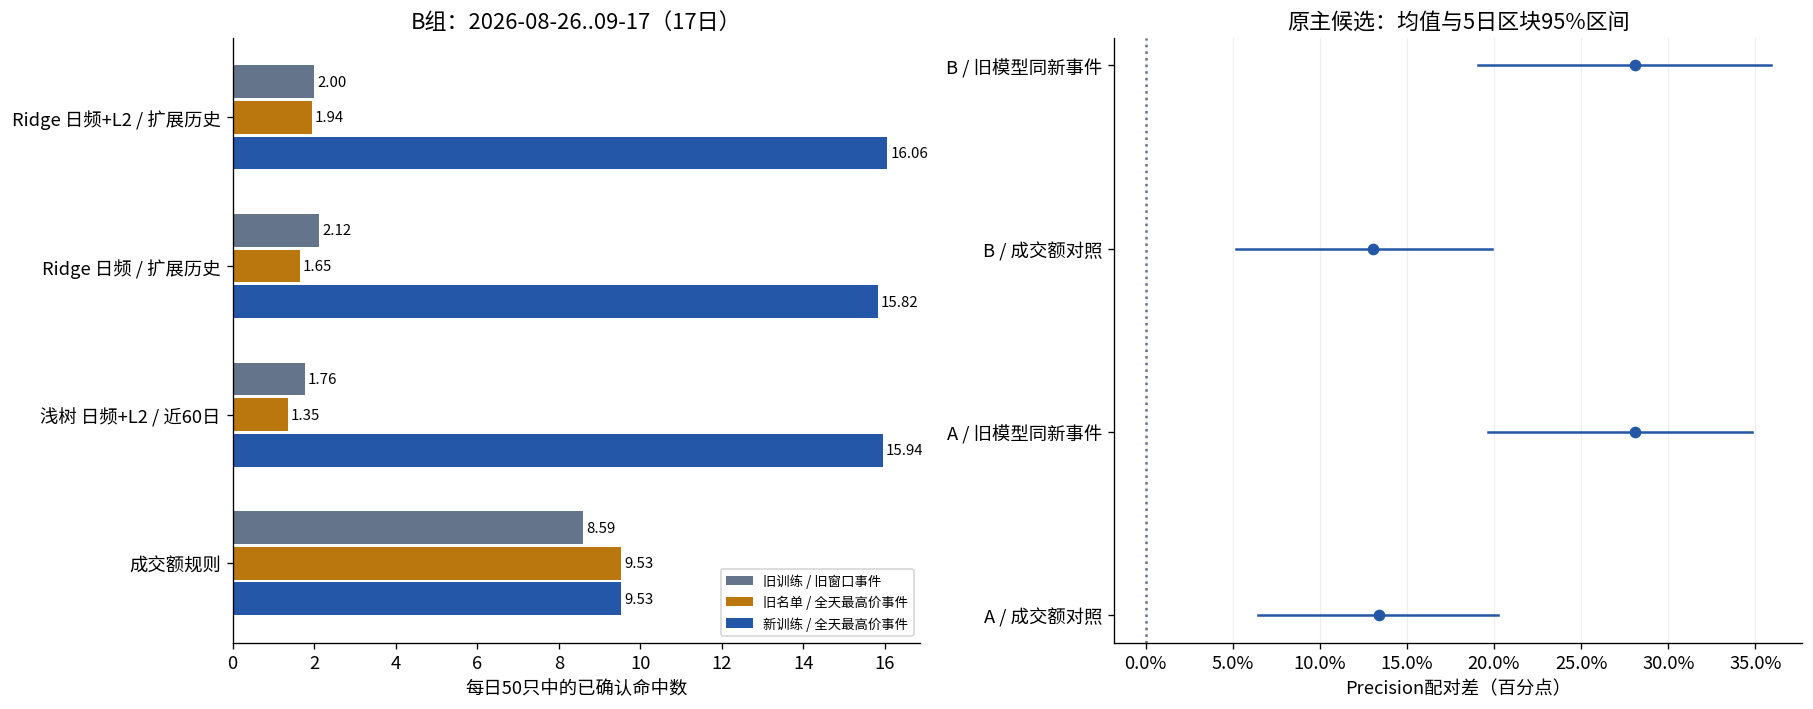

,experiment,method,hits,selected,precision_lower,precision_upper,recall_lower,f1_lower,lift_lower,label_coverage
22,corrected,baseline_amount,162,850,0.190588,0.190588,0.018141,0.033129,1.888979,1.000000
23,corrected,hist_all__last60,271,850,0.318824,0.318824,0.030356,0.055435,3.160782,1.000000
24,corrected,ridge_all__expanding,276,850,0.324706,0.325882,0.030915,0.056454,3.218927,0.998824
25,corrected,ridge_daily__expanding,275,850,0.323529,0.323529,0.030791,0.056230,3.206088,1.000000
48,extended,baseline_amount,162,850,0.190588,0.190588,0.018141,0.033129,1.888979,1.000000
49,extended,hist_all__last60,271,850,0.318824,0.318824,0.030356,0.055435,3.160782,1.000000
50,extended,ridge_all__expanding,273,850,0.321176,0.322353,0.030579,0.055841,3.183949,0.998824
51,extended,ridge_daily__expanding,269,850,0.316471,0.316471,0.030122,0.055009,3.136458,1.000000


In [10]:
figure, axes = plt.subplots(1, 2, figsize=(15, 5.8), layout="constrained")
roles = [
    parameters["primary"],
    "ridge_daily__expanding",
    "hist_all__last60",
    "baseline_amount",
]
for scenario, offset in [("old_old", -0.24), ("old_high", 0), ("high_high", 0.24)]:
    part = (
        summary.loc[
            summary.scenario.eq(scenario)
            & summary.experiment.eq("extended")
            & summary.period.eq("followup")
        ]
        .set_index("method")
        .loc[roles]
    )
    axes[0].barh(
        np.arange(len(roles)) + offset,
        part.mean_hits,
        height=0.22,
        color=colors[scenario],
        label=scenario_captions[scenario],
    )
    for position, value in zip(
        np.arange(len(roles)) + offset, part.mean_hits, strict=True
    ):
        axes[0].text(value + 0.08, position, f"{value:.2f}", va="center", fontsize=9)
axes[0].set_yticks(np.arange(len(roles)), [labels_map[m] for m in roles])
axes[0].invert_yaxis()
axes[0].set_xlabel("每日50只中的已确认命中数")
axes[0].set_title("B组：2026-08-26..09-17（17日）")
axes[0].legend(loc="lower right", fontsize=8)
axes[0].set_xlim(left=0)
view = primary_intervals.loc[
    primary_intervals.period.eq("followup")
    & primary_intervals.comparator.isin(["baseline_amount", "same_model_old_target"])
].reset_index(drop=True)
for position, row in enumerate(view.itertuples(index=False)):
    axes[1].plot(
        [row.two_sided_low, row.two_sided_high], [position, position], color="#2457a7"
    )
    axes[1].plot(row.mean_difference, position, "o", color="#2457a7")
axes[1].set_yticks(
    range(len(view)),
    [
        ("A" if r.experiment == "corrected" else "B")
        + " / "
        + ("成交额对照" if r.comparator == "baseline_amount" else "旧模型同新事件")
        for r in view.itertuples(index=False)
    ],
)
axes[1].axvline(0, color="#64748b", linestyle=":")
axes[1].xaxis.set_major_formatter(PercentFormatter(1))
axes[1].set_xlabel("Precision配对差（百分点）")
axes[1].set_title("原主候选：均值与5日区块95%区间")
axes[1].grid(axis="x", alpha=0.2)
figure.savefig(evidence / "followup-comparison.png", dpi=160)
plt.show()
display(
    summary.loc[
        summary.scenario.eq("high_high") & summary.period.eq("followup"),
        [
            "experiment",
            "method",
            "hits",
            "selected",
            "precision_lower",
            "precision_upper",
            "recall_lower",
            "f1_lower",
            "lift_lower",
            "label_coverage",
        ],
    ].round(6)
)

## 11. 保存证据与解释边界

所有输入运行后重新核对SHA-256；保留完整标签、收益、名单、模型、训练日程、分月指标及不确定性。
最高价收益仅检验潜在上行空间的横截面可预测性；没有定义如何在当天到达最高点时卖出。
结论不能外推为可实现收益，也不能把重复查看的历史当作新的最终验证集。

In [11]:
for record in input_manifest:
    assert sha256(Path(record["source"])) == record["sha256"]
    assert sha256(evidence / record["path"]) == record["sha256"]
main = primary_intervals.loc[
    primary_intervals.period.eq("followup")
    & primary_intervals.comparator.eq("baseline_amount")
].copy()
main["exploratory_support"] = main.mean_difference.gt(0) & main.one_sided_low.gt(0)
result = {
    "parameters": parameters,
    "input_files": len(input_manifest),
    "input_bytes": sum(r["size_bytes"] for r in input_manifest),
    "inputs_unchanged": True,
    "main_followup": json.loads(main.to_json(orient="records")),
    "no_new_holdout": True,
    "formal_data_writes": False,
    "models_published": False,
}
write_json(evidence / "result.json", result)
display(
    main[
        [
            "experiment",
            "mean_difference",
            "one_sided_low",
            "two_sided_low",
            "two_sided_high",
            "exploratory_support",
        ]
    ].round(6)
)
print(f"证据保存：{evidence}")

,experiment,mean_difference,one_sided_low,two_sided_low,two_sided_high,exploratory_support
177,corrected,0.134118,0.075294,0.064706,0.202353,True
375,extended,0.130588,0.065882,0.051765,0.198824,True


证据保存：/home/wsw/app/research-evidence/subscription-next-high-2026-09-22-mg7mzsz2


<a id="h06-protocol"></a>

## H06 2026-09-22 冻结方案与验收

运行前完整记录：[冻结 README](/home/wsw/app/research-evidence/subscription-next-high-2026-09-22-mg7mzsz2/source-README.md)。以下为便于阅读迁入的说明，原冻结记录不回写。

- 运行前固定：
  - 对照固定为修复后归档
    `/home/wsw/app/research-evidence/subscription-repaired-2026-09-22-2ans6qng/`。
    A 沿用181目标日、102开发日；B 沿用213目标日、134开发日，同时列共同102日。
    两组后续段均为已查看的 `2026-08-26..09-17`，17日；没有新的独立最终验证集。
  - 唯一训练变量是退出参考价。买入仍是 T 连续竞价 `[14:31,14:36)` 的实际分钟
    成交额之和/成交量之和，不改成14:30单点价。T+1 按正式交易日历确定；退出取该日
    沪深股票分钟事实中 `max(high)`，覆盖连续竞价及开收盘集合竞价。
  - `r_high = high(T+1)*factor(T+1)/(entry_vwap(T)*factor(T))-1`。
    与旧标签同样在 **T 日原 Feature universe** 的有效收益内执行升序、average-tie、
    valid-only 百分位排名；机会为严格 `rank > 0.9`。不是涨幅超过10%，也不先按
    原标签筛选机会。缺失/无效买价、最高价或因子保留 null。
  - T 盘前候选池、39列昨日特征、日期等权拟合、缺失填0.5、八个模型/窗口、
    月度重训、seed=20260919 和 K=50 全部沿用。主候选仍为 Ridge+L2/expanding；
    后续段仍只看主候选、Ridge日频消融、浅树+L2/last60及成交额规则。
    标签须到 T+1 全日结束才成熟，沿用 T+1 22:00可用的假设；不进入同期预测特征。
  - 同时列出旧训练/旧评价、旧名单/新评价、新训练/新评价，以区分事件定义变化和
    重训变化。补充同一新事件下新旧模型的配对差；不根据此诊断再选配置。
  - 主指标沿用日期等权 Precision、Recall、F1、Lift 及缺失界；所有原入选名额都在
    分母中。主比较为新模型 Precision 下界减成交额上界；另列实际池内随机期望和
    日频消融。5日循环区块重采样10,000次，seed=20260922，1/3日只作敏感性检查。
  - 当前更正数据版本只代表“假设正确数据及时到达”的历史情景；分钟 `high` 是
    当前源所观察到的全天成交高价，不证明可成交或当时实际收到该修订版本。
- Acceptance: 输入可恢复并锁定哈希；旧窗口标签在相同分钟/因子上重算一致；新收益
  不小于同股票旧参考收益；最高价包含竞价、跨交易日、复权、并列及缺失场景可复核；
  训练时序合法且特征逐值不变；保存模型可恢复预测；选池和命中计数独立重算；Notebook
  从头执行并检查图表。主差均值>0且5日区块单侧95%下界>0，至多称为探索性支持。
- Stop: 两组固定重训各执行一次；技术错误保留记录并在相同口径修复，不按结果更改
  日期、模型、阈值或 K。全部已查看历史上的区间均为探索性名义区间，不自动 adoption。

2026-09-22 的实验缘起：

- Why: 用户于2026-09-22提出退出价格变量实验，并明确选择用新标签重训，其他模型、
  特征和选股数量保持原方案。


<a id="h06-evidence"></a>

## H06 2026-09-22 结果、失败与归档

- Evidence（2026-09-22）：[`next_day_high.ipynb`](next_day_high.ipynb) 已从头执行11个
  代码单元，随后仅调整开发图的图例位置并重绘该单元。最终证据位于
  `/home/wsw/app/research-evidence/subscription-next-high-2026-09-22-mg7mzsz2/`；
  保存至用户决定及审查结束。源码快照与前次修复实验逐字节相同；训练实现没有变化。

**输入与标签核验**：冻结3,220份文件、6,206,672,670字节，包括原实验输入、面板、名单、
日程及本轮所需的214日沪深分钟和因子。共检查261,301,356条分钟行；全日最高价用
Arrow/Pandas分别聚合，买入窗口另以独立价量求和复算。213日旧参考窗口标签全部
逐值恢复；新收益均不低于对应旧收益。新标签全集有1,102,682个有效排名，最大并列组9；
22,708个证券日的竞价高价高于连续竞价高价，说明不能忽略竞价。
新前10%机会中，逐日平均76.3972%也属于旧前10%；该比例不是两个集合的Jaccard值。

仅替换标签后，原面板的证券、日期、时序与特征列逐值及类型相同；没有使用未来标签
是否存在来删减推理池。A/B保留181/213个目标日与原102/134个开发日。

**B组原主候选的三种口径**（Ridge+L2/扩展历史；Precision均为缺失保守下界）：

| 训练与评价 | 开发134日命中/6,700 | Precision | 原后续17日命中/850 | Precision |
| --- | ---: | ---: | ---: | ---: |
| 旧训练，旧14:30退出事件 | 249 | 3.7164% | 34 | 4.0000% |
| 旧名单，改用次日最高价事件 | 172 | 2.5672% | 33 | 3.8824% |
| 新标签重训，次日最高价事件 | 2,190 | **32.6866%** | 273 | **32.1176%** |

新训练主候选平均每天50只中命中 **16.34只、16.06只**。开发段18个、后续段1个
入选标签未知，Precision上界分别为32.9552%、32.2353%。同一新事件下，随机期望界
分别为9.9844%–10.1322%、9.9959%–10.0897%；主候选Lift下界为3.2272、3.1839。
后续段Recall界为3.0579%–3.0964%，F1界为5.5841%–5.6500%，均为日期等权结果。

**B组同一新目标下的固定对照**：

| 方案 | 开发134日 Precision下界 | 原后续17日 Precision下界 |
| --- | ---: | ---: |
| 原主候选：Ridge+L2/扩展历史 | 32.6866% | 32.1176% |
| 日频消融：Ridge/扩展历史 | 33.2985% | 31.6471% |
| 原参照：浅树+L2/近60日 | 34.9851% | 31.8824% |
| 成交额规则 | 24.2687% | 19.0588% |
| 动量规则 | 32.8806% | 未安排，不追加评价 |

八模型在B开发段的Precision下界范围为32.6866%–35.6119%，均高于相同池的随机期望
上界；其中35.6119%为浅树日频/扩展历史，仅完整披露观察结果，没有改选后续主候选。
动量规则与原主候选接近，不能将超过成交额对照写成超过所有简单规则。

**主配对差及不确定性**（新训练主候选下界减同一新事件下成交额上界）：

| 组别与区间 | 均值差（百分点） | 5日区块双侧95%区间 | 单侧95%下界 |
| --- | ---: | ---: | ---: |
| A 开发102日 | +8.6471 | [+6.2157, +11.2549] | +6.5294 |
| B 开发134日 | +8.3881 | [+6.3134, +10.5522] | +6.6269 |
| A 原后续17日 | +13.4118 | [+6.4706, +20.2353] | +7.5294 |
| B 原后续17日 | +13.0588 | [+5.1765, +19.8824] | +6.5882 |

A主候选后续为276/850（32.4706%）。共同102日的新训练主候选A/B命中率分别为
33.1569%和32.5686%。B在同一新事件下相对自身旧模型的后续保守差为+28.1176个百分点，
双侧95%区间[+19.0588, +35.8824]。这支持改善来自针对新目标的重训，而不只是
对固定旧名单换一种评价方式；它不是对“日内波动误差”的因果识别。

B后续主候选相对纯日频的保守差仅+0.4706个百分点，双侧95%区间
[−2.1206, +3.4118]；开发段方向相反，仍没有稳定L2增量证据。全部1/3/5日区块区间和
分月结果均保存，未挑选有利区间。两组均达到相对成交额规则的预设探索性支持条件；
历史区间已经被查看，这些名义区间不构成独立最终确认。

**工程复核**：110次拟合的模型全部重载，574份逐日预测逐值恢复；2,732个模型日
独立重选名单及核对计数，5,464次sklearn极端事件赋值核验缺失界；原旧事件指标全部
恢复，主配对bootstrap另用显式索引循环复算。3,220份源/副本在运行后哈希未变。
Notebook的Ruff检查、格式检查和导出代码定向Mypy通过；相关窗口、复权、预处理、
数据集与推理测试 **67 passed**。未运行无关全仓库测试，未重新解压全量raw或核验
逐笔经济真实性；结论受源端事实和历史版本可用性限制。

两次训练前的技术失败分别为证据清单中的Path序列化、面板join后的证券列dtype变化；
已修复，保留严格断言。失败代码、输入和日志分别在同级 `g8is5g_8`、`akl8kttv`
结尾的证据目录，没有产生可用于挑选模型的训练结果。第二次已完成的价格/标签与最终
运行一致；它们不是独立实验。图例遮挡修正在完成的Notebook与独立绘图重渲染记录中保留。


<a id="h06-cause-l2-diagnostics"></a>

## H06 2026-09-23 原因诊断的背景与当时解释

以下是 2026-09-23 的解释记录；当前研究判断仍见 [README 的 H06](README.md#h06-次日全天最高价标签的单变量重训)，后续已执行的验证见 H07/H08。

本节按用户要求记录 H06 结果的解释、补充统计及解决方向，属于既有研究记录维护。
H06 保持 open、本地 draft；未改变原 Acceptance、选择模型或正式 owner。以下方向尚未
冻结成下一轮实验，不新建假设编号，也不表示用户已经采用分类器、新特征或交易策略。
该段保留提出方向时的状态；用户随后要求执行验证，首轮方案及证据见 [H07](README.md#h07-事件概率训练与现有l2分组消融)。

**当前判断**：现有证据不支持“L2 本身没有用”。重训后模型明显转向高波动、高换手和
近期偏强的股票，纯日频也能识别这些状态；当前 L2 又是滞后一日、窗口有限、重复度较高的
成交摘要。因此，更符合观察的解释是目标变化后日频已提供主要可用预测模式，而这组 L2
没有显示稳定的额外优势。信息重复、表达和时效性的各自贡献尚未被独立实验识别，不能
把这一解释升级为唯一因果机制，也不能保证补全 L2 后一定改善。


<a id="h06-model-diagnostics"></a>

## H06 2026-09-23 补充结果与模型行为

H06 的 B 组在同一最高价事件下，旧名单后续17日命中33/850（3.8824%），重训后为
273/850（32.1176%），纯日频为269/850（31.6471%）。L2 只多4次确认命中；相对日频的
保守配对差为+0.4706个百分点，5日区块名义95%区间为[−2.1206, +3.4118]个百分点。
开发134日则是纯日频33.2985%高于日频+L2的32.6866%。这些事实既没有证明稳定正增量，
也没有证明严格等效；旧名单换评价口径与针对新目标重训的完整对照见 H06 原结果。

新旧目标都以 T 日 `[14:31,14:36)` 的 VWAP 为买入基准；旧目标要求 T+1 同窗价格较高，
新目标只要求 T+1 全天曾出现较高成交价。最高价目标更容易体现振幅和右尾机会，即使
冲高后回落也可能取得较高标签；固定时点收益则不会保留此前全部上冲。这不是正例比例
自动变大：机会始终为各自有效收益的横截面前10%，变化的是哪些状态能够预测该事件。

补充读取保存名单与冻结特征，得到后续17日入选股票的平均横截面分位：

| 历史特征（0..100分位） | 旧模型+L2 | 新模型+L2 | 新模型纯日频 |
| --- | ---: | ---: | ---: |
| 60日波动率 | 18.1 | 92.3 | 95.0 |
| 20日平均换手率 | 12.2 | 85.8 | 91.5 |
| 5日收益 | 51.5 | 82.5 | 89.8 |

这些数值是特征分位的均值，不是收益率、波动率本身或因果贡献比例。先在每日入选股票内
对非缺失特征求均值，再对17日等权；历史窗仍按既有 `asof_tminus1` 定义，不引入 T 日信息。
模型从低波动、低换手名单转向高波动、活跃且近期偏强的名单，是实际模型行为证据。

另一个重要限制是**训练优化平均未来排名，评价却要求抓住前10%事件**。开发134日按事前
60日波动率分位分组，在标签已知样本中先求逐日组内均值、再对日期等权：

| 波动率组 | 旧目标平均排名 | 旧目标前10%比例 | 新目标平均排名 | 新目标前10%比例 |
| --- | ---: | ---: | ---: | ---: |
| 最低20% | 0.5161 | 4.78% | 0.3987 | 2.78% |
| 最高20% | 0.4850 | 16.73% | 0.5877 | 19.80% |

高波动组可以同时包含更多赢家和输家：旧目标的平均排名略低，前10%机会却更多。
因此，排名回归偏好的股票群体不一定是命中率最优群体；换成最高价目标后，平均排名与
高波动组的上冲机会更一致。这支持继续比较事件概率目标，但尚未实际证明分类器优于
当前回归模型，也没有证明原目标只因“日内噪声”而失败。


<a id="h06-l2-coverage"></a>

## H06 2026-09-23 当时 L2 覆盖与表达核对

现有实现将七列日频分位与32列 P 日 H03 特征合并，缺失填0.5，训练 Ridge 或浅树。
32列来自截至 P 日14:30的5/15/30/60分钟嵌套窗口，最长为 `[13:30,14:30)`；其中28列
是横截面排名，四列是实际存在成交分钟的覆盖比例。公式和方向语义分别见
[Feature owner](../../docs/data/stock_1430_feature_label_contract.md#feature-schema-与计算)、
[逐笔 owner](../../docs/data/level2_normalization.md)。

1. **信息重复有直接证据。** 在213个目标日的冻结特征面板上，分别计算每日成对非缺失
   特征的 Pearson 相关系数，再对日期等权平均，结果如下：

   | 特征对 | 平均相关系数 |
   | --- | ---: |
   | 日频成交额分位 / L2 60分钟成交额分位 | 0.9454 |
   | L2 5分钟成交额分位 / L2 60分钟成交额分位 | 0.9062 |
   | L2 60分钟有符号成交量比分位 / 有符号成交额比分位 | 0.99999 |

   窗口内价格相对接近时，成交量加权和成交额加权的方向比率本来就可能非常相似。
   32列不等于32份独立信息；高相关不能单独证明条件预测信息为零，但说明增加列数
   并不自动增加日频之外的信息。
2. **特征覆盖确实有限。** 当前统计不包含完整早盘、14:30之后的尾盘及竞价过程，
   没有完整盘口深度、价差、新增委托、撤单、补单、队列消耗或成交大小分布。
   `tick_signed_*` 只由价格变化决定方向，同价记0；不能识别同价成交背后的真实
   主动买卖，不能解释为主力资金流。覆盖不足成立，补全后的收益尚未验证。
3. **时间尺度可能不匹配。** 用 P 日一个小时的摘要在 T 盘前选池，目标涉及 T 下午
   买入和 T+1 高点；短时供需压力不一定跨日持续。历史 L2 应检验能否提取跨日延续的
   活跃、异常成交或尾盘结构。当日 L2 的价值需要另一个受实际订阅约束的实验。
4. **表达压缩可能损失信息。** 百分位保留相对排序，却不完整保留绝对强度、相对股票
   自身历史的异常程度；窗口净和、边缘收益及振幅也不足以恢复事件顺序、持续单边
   行为和冲高回落路径。四个窗口保留了部分结构，不能视作完整成交序列。
5. **学习器只检验了有限的使用方式。** Ridge 主要学习加法关系，未必表达某个 L2
   信号只在特定波动、流动性或市场状态下有效的交互；但浅树也没有明显摆脱日频
   水平，不能把原因全部归于线性模型，也没有证据保证深度网络能解决。

L2 确实进入训练并影响预测，不是单纯没有接入。归档主模型使用39列特征且有非零 L2
系数；后续17日日频+L2与纯日频top50名单平均仅重合22只（每日17..28只）。L2明显
改变了名单，但改变没有带来稳定净增量。小幅命中差不能解释成模型完全忽略了 L2。

| 用户提出的解释 | 当前证据支持的判断 |
| --- | --- |
| L2本身无用 | 不能成立为一般结论；本轮仅检验一组历史成交摘要 |
| 加入方式不合适 | 时间尺度、表达和训练目标有具体局限；尚未识别哪项主导 |
| L2特征不完整 | 覆盖层面明确成立；补齐后的预测和经济价值均待验证 |

外部方法依据：[Cont、Kukanov、Stoikov 的订单簿事件研究](https://arxiv.org/abs/1011.6402)
讨论短时间尺度内委托、成交和撤单形成的订单流不平衡与价格变化，支持区分成交量摘要
和完整供需事件。该研究不证明本市场、昨日信息或次日最高价任务存在可交易优势。


<a id="h06-research-directions"></a>

## H06 2026-09-23 当时提出的研究方向与对照设计

这是提出方向时的历史记录；首项与现有分组消融后来形成 H07。当前未形成 Change 的想法见 [README](README.md#未来想法)。

以下为未来想法及建议次序，尚未执行、冻结预算或确定独立验证日期。用户本次要求记录
不构成启动全部实验或 adoption 的决定；实际执行前再按独立采用边界注册相应假设。

1. **先对齐事件目标并加强日频对照。** 保持最高价事件、K=50、样本、特征和时间边界，
   有限比较排名回归、正则事件概率分类和一个有限复杂度的非线性分类模型；每种均做
   日频与日频+现有L2配对。主指标为 Precision@50及L2增量，另看概率校准、Brier或
   log loss。加入波动率、动量等事前规则对照；开发期动量已达32.8806%，超过成交额
   不能视为超过全部简单规则。只有更换学习方式后L2出现稳定额外改善，才支持原方式
   限制了这组L2；分类器也可能仅改善日频，不证明L2有效。
2. **先分组消融，再补完整昨日成交过程。** 当前L2按价格/振幅、活跃度/规模、方向代理
   分组，分别加入日频并重新拟合；不把相关单列的重要性当增量证据。随后固定模型和
   目标，分开比较原窗口、完整昨日、表达改进：补早盘/午后/尾盘及竞价；构造相对过去
   同时段的异常成交和振幅、方向持续性及跨日变化、单位成交对应的价格变化、成交大小
   分布。保留必要原始比率，并用当时可用历史估计归一化尺度；新增字段仍须核对覆盖及
   缺失语义，不能用未来标签可用性调整选池。
3. **将盘口、委托和撤单作为独立信息增量。** 先建立字段含义、事件顺序、订单身份及
   盘口恢复的可靠边界，再检验深度不平衡、价差、补撤单和队列消耗。对照为日频+
   完整成交信息与再加入盘口/委托信息；有 raw 文件不等于已有可训练能力，不混改
   当前正式 schema 或生产入口。
4. **单独验证当日实时L2的行动价值。** 候选方向是盘前用日频/历史信息选池，实际订阅
   后再辅助是否执行、执行时机与价格、已有持仓管理。固定同一池、决策时刻、仓位和
   执行/退出规则，对照也使用当时实际可得的普通行情；按已收消息裁剪、初始化，禁止
   补看订阅前历史。评价成本、成交、持有约束及完整效用，不能用短期预测提升替代
   可实现收益。此项不回答昨日L2的盘前选池增量，二者不可混报。
5. **提前固定确认和停止条件。** 已查看历史用于开发，冻结有限候选和调参预算后用新
   日期确认；按日期配对和区块重采样，补波动率、流动性、板块、月份分组诊断。
   最低有用增量须事前确定；区间跨零仅表示不确定，不能据此证明无用。若合理候选在
   足够精度下仍达不到最低有用增量，才支持停止为这个具体任务增加L2复杂度。

区分原因时保持对照变量明确：原特征改表达后改善支持使用方式问题；补全昨日成交后
改善支持窗口或历史表征不足；加入盘口后改善支持缺少独有供需信息；只有当日L2改善
支持时效性与任务匹配问题。即使出现上述结果，也只支持相应实验范围内的解释，不是
对某类数据永久有效或无效的判决。建议首先执行“事件概率训练+日频强对照+现有L2分组
消融”，再决定是否补完整昨日成交；最高价监督不能直接作为实际卖价或净收益。


<a id="h06-diagnostics-reproduce"></a>

## H06 2026-09-23 补充统计来源与只读复算

本节统计为2026-09-23对既有冻结结果的事后描述，没有重训、改名单或消耗新的最终
验证区间。基线为 `46ecdc1dba1a390cf7cfe8560f296cb7fcd0cbbf`；数据根为 H06 归档
`/home/wsw/app/research-evidence/subscription-next-high-2026-09-22-mg7mzsz2/`。
训练源码与归档 `source-validate_training.py` 相同，SHA-256为
`518598f6aea2e2a74b07ce0ad1442b8a3fb6964addb4a2c9c8686bbbb2ff23eb`。
下面四份输入均与归档 `artifact-manifest.json` 的内容摘要相符，原内容及清单按 H06
保留期保留；本节不覆盖旧归档。

| 输入（相对归档根） | SHA-256 |
| --- | --- |
| `panel.parquet` | `dd010bd88392132b7b6134a7893bd68d3925a68d3c2300db53aab4a73f632323` |
| `candidate-labels.parquet` | `c81c4a49027edeb302485a85f6d0c2c454c96099f31ab57c66e99d39da5d8c8d` |
| `rank-daily.parquet` | `1b28660d36ab0cfed3f20808655e0edd9954e8fee0205753003b38f74e0d30fc` |
| `baseline/rank-daily.parquet` | `4144881ca70d1f9fb6ca92028125c0333b48538c8765dcfd8c09faad87a1db48` |

特征相关使用完整213日 `2025-11-06..2026-09-17`；波动分组使用开发134日
`2026-02-03..08-24`，最低组为分位 `(0,0.2]`、最高组为 `(0.8,1]`；名单画像及重合
使用后续17日 `2026-08-26..09-17` 的 B 组。分组的已知标签比例仅是描述统计，不替代
H06 对选池缺失标签保留的上下界。未重新解压全量 raw，未增加经济真实性、真实接收或
历史修订版本当时可用的证明。

<details>
<summary>补充表格和名单重合的只读复算命令</summary>

在仓库根使用 H06 锁定环境（Pandas 3.0.2、PyArrow 25.0.0）执行；仅读取归档并输出统计。

```bash
.venv/bin/python -B - <<'PY'
from pathlib import Path
import hashlib
import json
import pandas as pd

root = Path('/home/wsw/app/research-evidence/subscription-next-high-2026-09-22-mg7mzsz2')
manifest = {item['path']: item for item in json.loads((root / 'artifact-manifest.json').read_text())}
tables = {}
for name in ['panel.parquet', 'candidate-labels.parquet', 'rank-daily.parquet', 'baseline/rank-daily.parquet']:
    with (root / name).open('rb') as stream:
        assert hashlib.file_digest(stream, 'sha256').hexdigest() == manifest[name]['sha256']
    tables[name] = pd.read_parquet(root / name)
panel = tables['panel.parquet']
vol = 'lag_f_d_close_volatility_60d_asof_tminus1_rank'
features = [vol, 'lag_f_d_turnover_rate_mean_20d_asof_tminus1_rank', 'lag_f_d_close_return_5d_asof_tminus1_rank']
lists = {}
for label, filename, method in [
    ('old_all', 'baseline/rank-daily.parquet', 'ridge_all__expanding'),
    ('new_all', 'rank-daily.parquet', 'ridge_all__expanding'),
    ('new_daily', 'rank-daily.parquet', 'ridge_daily__expanding'),
]:
    frame = tables[filename]
    chosen = frame.loc[frame.experiment.eq('extended') & frame.method.eq(method)
                       & frame.trade_date.between('2026-08-26', '2026-09-17')]
    assert len(chosen) == 17
    lists[label] = chosen.set_index('trade_date').selected_symbols
    keys = chosen[['trade_date', 'selected_symbols']].explode('selected_symbols').rename(columns={'selected_symbols': 'symbol'})
    values = keys.merge(panel[['trade_date', 'symbol', *features]], on=['trade_date', 'symbol'], validate='one_to_one')
    assert len(values) == 850
    print(label, values.groupby('trade_date')[features].mean().mean() * 100)
overlap = pd.Series({day: len(set(symbols) & set(lists['new_daily'].loc[day]))
                     for day, symbols in lists['new_all'].items()})
print('top50_overlap_mean_min_max', overlap.mean(), overlap.min(), overlap.max())

joined = panel[['symbol', 'trade_date', vol]].merge(
    tables['candidate-labels.parquet'][['symbol', 'trade_date', 'old_rank', 'high_rank']],
    on=['symbol', 'trade_date'], how='left', validate='one_to_one',
)
joined = joined.loc[joined.trade_date.between('2026-02-03', '2026-08-24')].copy()
joined['vol_group'] = pd.cut(joined[vol], [0, .2, .8, 1], labels=['low20', 'middle60', 'high20'])
for target in ['old', 'high']:
    rank = joined[f'{target}_rank']
    joined[f'{target}_event'] = rank.gt(.9).astype(float).where(rank.notna())
columns = ['old_rank', 'old_event', 'high_rank', 'high_event']
daily = joined.groupby(['trade_date', 'vol_group'], observed=True)[columns].mean()
print(daily.groupby('vol_group', observed=True).mean().loc[['low20', 'high20']])

for left, right in [
    ('lag_f_d_log_amount_rank', 'lag_f_l2_notional_rank_60m'),
    ('lag_f_l2_notional_rank_5m', 'lag_f_l2_notional_rank_60m'),
    ('lag_f_l2_tick_signed_volume_ratio_rank_60m', 'lag_f_l2_tick_signed_notional_ratio_rank_60m'),
]:
    correlations = [day[[left, right]].corr().iloc[0, 1] for _, day in panel.groupby('trade_date')]
    print(left, right, pd.Series(correlations).mean())
PY
```

</details>


<a id="h06-reproduce"></a>

## H06 重训结果的精确恢复

H06使用 `next_day_high.ipynb` 与 `trading-research` 内核；正常从头执行会读取当前价格输入
并新建隔离证据目录。准确恢复本次结果时，将其归档 `source.tar` 解入独立源码目录，
使用归档源码Notebook与锁定环境。`baseline/` 保存控制面板、原名单和全部历史特征/标签；
`facts/` 保存本次全部价格输入，`input-manifest.json` 绑定内容，`upstream-metadata/`
保存直接上游身份。重放计算单元时直接读取这两份已冻结研究副本，不将其当作完整正式
存储根调用Access或写回正式数据；原正式Meta所引用的全量逐笔没有复制，也不参与
本次候选计算。`next_day_high.html` 是含实际输出的浏览版本。
